In [64]:
#Import Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve


*Load Data Sets and review their content and columns to answer the docx.*

In [65]:
#Load all the datasets
olist_payments = pd.read_csv("olist_order_payments_joined.csv")
olist_orders = pd.read_csv("olist_order_items_joined.csv")

In [66]:
#Drop all the columns that are duplicated and merge the two datasets into one called 'olist' 
olist_orders.drop(['customer_id','order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date','order_estimated_delivery_date', 'review_score','total_payment', 'customer_unique_id','customer_zip_code_prefix','customer_city','customer_state'], axis=1, inplace=True)
olist = pd.merge(olist_payments, olist_orders, on='order_id', how='outer')

In [67]:
#check the names of each column 
olist.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'customer_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'review_score', 'total_payment',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state'],
      dtype='object')

### Classification and Logistic Regression: 

In [68]:
olist.dtypes
#We see that all the variables we are going to use are of the right type. 

order_id                          object
payment_sequential               float64
payment_type                      object
payment_installments             float64
payment_value                    float64
customer_id                       object
order_status                      object
order_purchase_timestamp          object
order_approved_at                 object
order_delivered_carrier_date      object
order_delivered_customer_date     object
order_estimated_delivery_date     object
review_score                     float64
total_payment                    float64
customer_unique_id                object
customer_zip_code_prefix           int64
customer_city                     object
customer_state                    object
order_item_id                    float64
product_id                        object
seller_id                         object
shipping_limit_date               object
price                            float64
freight_value                    float64
product_category

In [69]:
olist['review_score'].fillna(0,inplace=True)

/var/folders/14/m1vb_x1x1ss2xkp4kjys3b_m0000gn/T/ipykernel_51225/1156868888.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  olist['review_score'].fillna(0,inplace=True)


In [70]:
#drop the null values
olist.dropna(inplace=True)

In [71]:
olist.review_score.value_counts()

review_score
5.000000    64705
4.000000    21658
1.000000    12712
3.000000     9496
2.000000     3799
0.000000      849
4.500000       78
2.500000       44
3.500000       29
1.500000       18
3.333333        1
4.333333        1
Name: count, dtype: int64

### Show the summary Statistics table with coefficient, standard error, t-value and p-value
#### Show for 4 key x variables: payment_type, price, freight_value, delivery_time

In [72]:
# Ensure that 'review_score' is available, and create a binary variable 'review_given'
olist['review_given'] = olist['review_score'].apply(lambda x: 1 if x > 0 else 0)

In [73]:
# Calculate delivery_time as the difference between order delivered and purchase timestamp
olist['order_purchase_timestamp'] = pd.to_datetime(olist['order_purchase_timestamp'])
olist['order_delivered_customer_date'] = pd.to_datetime(olist['order_delivered_customer_date'])
olist['delivery_time'] = (olist['order_delivered_customer_date'] - olist['order_purchase_timestamp']).dt.days

ROC AUC Score: 0.6027273484514184
Optimization terminated successfully.
         Current function value: 0.043836
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:           review_given   No. Observations:                79373
Model:                          Logit   Df Residuals:                    79366
Method:                           MLE   Df Model:                            6
Date:                Fri, 29 Nov 2024   Pseudo R-squ.:                 0.01804
Time:                        08:51:09   Log-Likelihood:                -3479.4
converged:                       True   LL-Null:                       -3543.3
Covariance Type:            nonrobust   LLR p-value:                 3.669e-25
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        4.9293      0.042

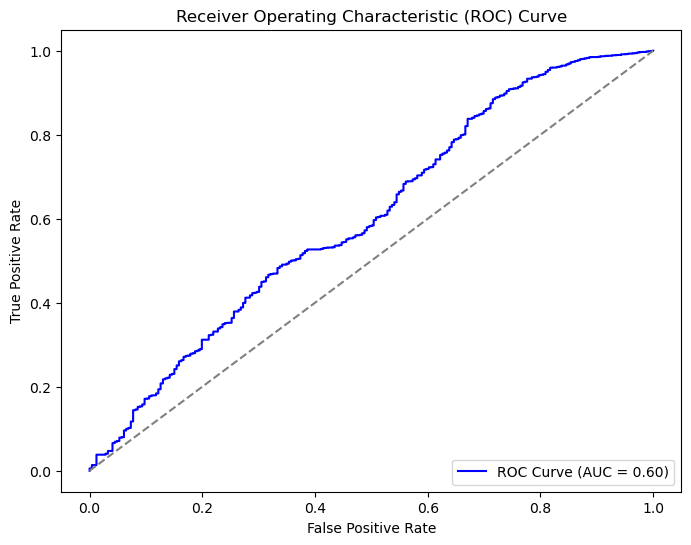

In [49]:
# Verify relevant columns
features = ['payment_type', 'price', 'freight_value', 'order_delivered_customer_date']

olist.dropna(subset=features, inplace=True)

# Define independent (X) and dependent (y) variables
X = olist[['payment_type', 'price', 'freight_value', 'delivery_time']]
y = olist['review_given']

# Convert 'payment_type' into dummy variables (one-hot encoding)
X = pd.get_dummies(X, drop_first=True)  # The first category is dropped to avoid multicollinearity

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert X_train_scaled to a pandas DataFrame with column names
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)  # Keep indices
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)  # Keep indices

# Add constant for the intercept
X_train_sm = sm.add_constant(X_train_scaled_df)

# Create the Logistic Regression model and fit it
model = LogisticRegression(max_iter=200, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# Get predictions and calculate the ROC AUC
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC AUC Score:", roc_auc)

# Create summary table with statsmodels
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()

# Print the summary table with the correct column names
print(result.summary())

# Calculate and plot the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random line
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


/var/folders/14/m1vb_x1x1ss2xkp4kjys3b_m0000gn/T/ipykernel_51225/3350594949.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=olist, x='review_given', y='price', palette='coolwarm')


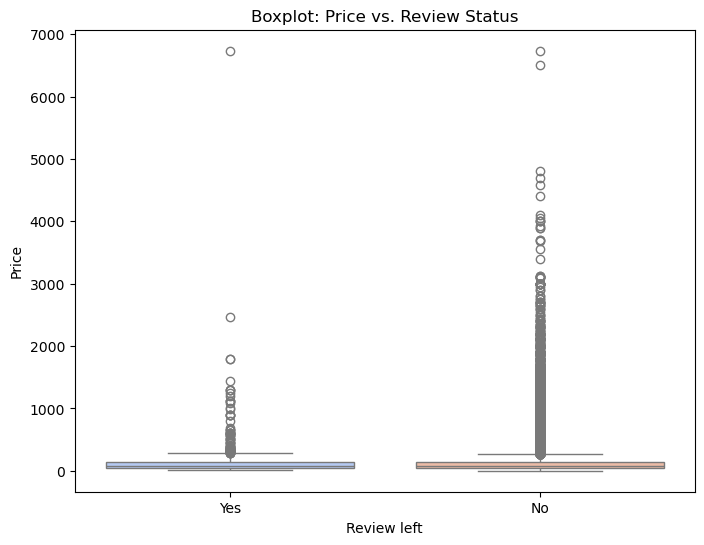

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot: Price vs Review Status (Review Given = 1 or 0)
plt.figure(figsize=(8, 6))
sns.boxplot(data=olist, x='review_given', y='price', palette='coolwarm')

# Add labels and title
plt.title('Boxplot: Price vs. Review Status')
plt.xlabel('Review left')
plt.ylabel('Price')
plt.xticks([0, 1], ['Yes', 'No'])  # Set x-tick labels
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


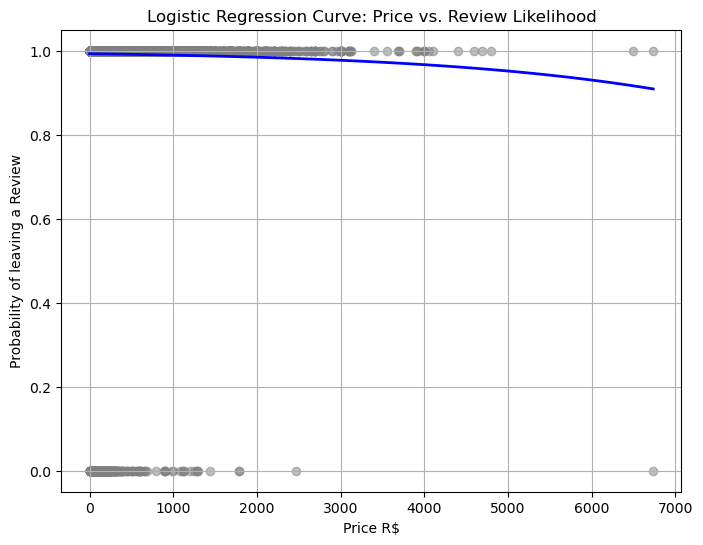

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Define the logistic regression model
logreg = LogisticRegression(solver='liblinear')

# Fit logistic regression model for price
X_price = olist[['price']]  # Use 'price' as the predictor variable
y = olist['review_given']   # Binary outcome: whether a review was given or not

# Fit logistic regression model
logreg.fit(X_price, y)

# Predict probabilities for a range of prices
price_range = np.linspace(X_price['price'].min(), X_price['price'].max(), 100).reshape(-1, 1)
probabilities = logreg.predict_proba(price_range)[:, 1]  # Probability of review being given (1)

# Plot the logistic regression curve
plt.figure(figsize=(8, 6))
plt.scatter(X_price, y, color='gray', alpha=0.5)  # Plot actual data points
plt.plot(price_range, probabilities, color='blue', lw=2)  # Logistic regression curve

# Add labels and title
plt.title('Logistic Regression Curve: Price vs. Review Likelihood')
plt.xlabel('Price R$')
plt.ylabel('Probability of leaving a Review')
plt.grid(True)
plt.show()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


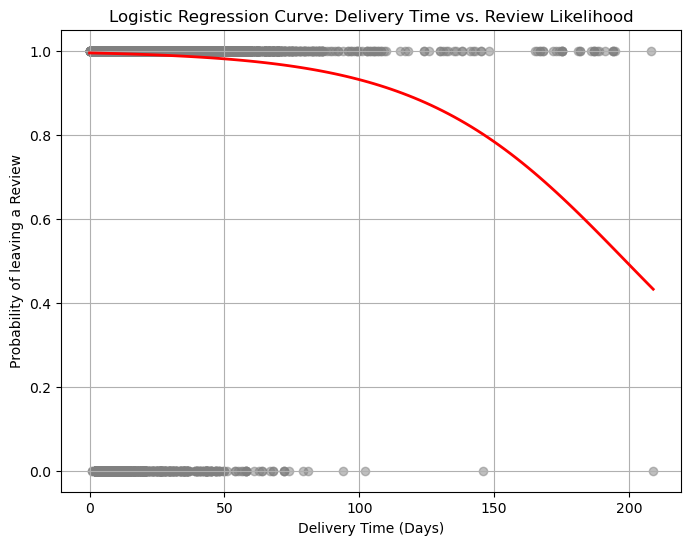

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Define the logistic regression model
logreg = LogisticRegression(solver='liblinear')

# Fit logistic regression model for delivery time
X_delivery_time = olist[['delivery_time']]  # Use 'delivery_time' as the predictor variable
y = olist['review_given']   # Binary outcome: whether a review was given or not

# Fit logistic regression model
logreg.fit(X_delivery_time, y)

# Predict probabilities for a range of delivery times
delivery_time_range = np.linspace(X_delivery_time['delivery_time'].min(), X_delivery_time['delivery_time'].max(), 100).reshape(-1, 1)
probabilities = logreg.predict_proba(delivery_time_range)[:, 1]  # Probability of review being given (1)

# Plot the logistic regression curve
plt.figure(figsize=(8, 6))
plt.scatter(X_delivery_time, y, color='gray', alpha=0.5)  # Plot actual data points
plt.plot(delivery_time_range, probabilities, color='red', lw=2)  # Logistic regression curve

# Add labels and title
plt.title('Logistic Regression Curve: Delivery Time vs. Review Likelihood')
plt.xlabel('Delivery Time (Days)')
plt.ylabel('Probability of leaving a Review')
plt.grid(True)
plt.show()


In [62]:
from sklearn.metrics import f1_score

# Predict the labels for the test set
y_pred = model.predict(X_test_scaled)

# Calculate the F1 score
f1 = f1_score(y_test, y_pred)

print(f"F1 Score: {f1:.2f}")

F1 Score: 0.83


/var/folders/14/m1vb_x1x1ss2xkp4kjys3b_m0000gn/T/ipykernel_51225/3728813430.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='review_given', data=olist, palette='viridis')


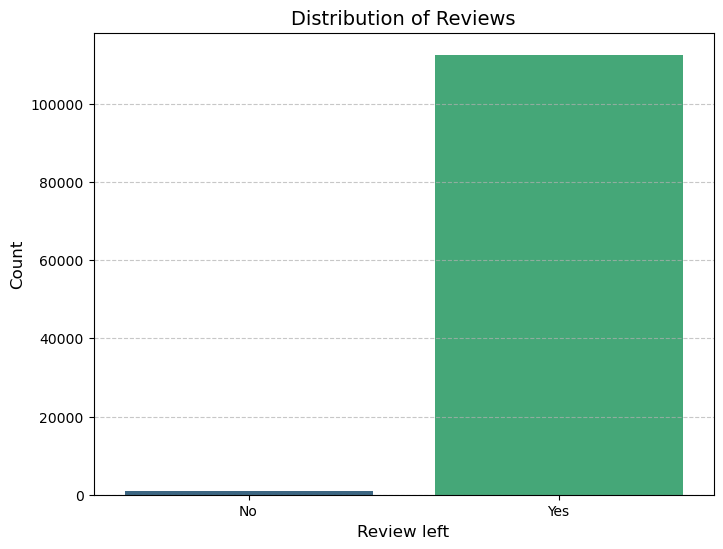

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of reviews
plt.figure(figsize=(8, 6))
sns.countplot(x='review_given', data=olist, palette='viridis')

# Add labels and title
plt.title('Distribution of Reviews', fontsize=14)
plt.xlabel('Review left', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([1, 0], ['Yes', 'No'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [78]:
olist.review_given.value_counts()

review_given
1    112541
0       849
Name: count, dtype: int64